# 02 - Tail Label Check

This notebook presents the B-module result as the point where cleaned prices become a model-ready conditional dataset.

The key question for the reader is no longer "did the code run?" but rather:
- What exactly is being predicted and conditioned on?
- How are tail events represented in the dataset?
- Are the train, valid, and test splits informative enough for the next stage of the project?


## Key takeaways before reading the tables

Current repository outputs support these statements:
- `features.parquet` already contains return, tail-loss, and 4 condition factors on the balanced panel.
- `dataset_train.npz`, `dataset_valid.npz`, and `dataset_test.npz` are not generic files; they are the exact tensor interface consumed by C-module.
- The train and test tail ratios are both close to the intended 5% tail definition, which is good for MVP experiments.
- The validation period is unusually calm and therefore under-represents stress events.
- The later calibration grid in C/D kept this B-module dataset fixed, so the observed tradeoff between `42 / 1.0` and `42 / 3.0` should be interpreted as a training/sampling effect rather than a dataset change.

This last point is the main thing a serious reader needs to notice. It does not break the pipeline, but it does affect how validation results should be interpreted.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path('data').exists() and Path('outputs').exists():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == 'notebooks' and Path('../data').exists() and Path('../outputs').exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError('Cannot locate project root from current notebook working directory.')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)


In [2]:
FEATURES_PATH = PROJECT_ROOT / 'data/processed/features.parquet'
TRAIN_PATH = PROJECT_ROOT / 'data/processed/dataset_train.npz'
VALID_PATH = PROJECT_ROOT / 'data/processed/dataset_valid.npz'
TEST_PATH = PROJECT_ROOT / 'data/processed/dataset_test.npz'
COMP_PATH = PROJECT_ROOT / 'outputs/tables/b_dataset_composition.csv'
DESC_PATH = PROJECT_ROOT / 'outputs/tables/b_feature_descriptive_stats.csv'

for p in [FEATURES_PATH, TRAIN_PATH, VALID_PATH, TEST_PATH, COMP_PATH, DESC_PATH]:
    assert p.exists(), f'Missing file: {p}'

features = pd.read_parquet(FEATURES_PATH).copy()
features['trade_date'] = pd.to_datetime(features['trade_date'])
features = features.sort_values('trade_date').reset_index(drop=True)
composition = pd.read_csv(COMP_PATH)
descriptive = pd.read_csv(DESC_PATH)

features.head()


,trade_date,portfolio_return,tail_loss,cumret_5d,vol_20d,amount_change_5d,portfolio_amount,asset_count,split,ret_hs300_etf,ret_zz500_etf,ret_cyb_etf,ret_cyb50_etf,ret_kc50_etf,y_tail,high_vol
0,2020-11-16,NaN,NaN,NaN,NaN,NaN,5.766900e+09,5,train,NaN,NaN,NaN,NaN,NaN,0,0
1,2020-11-17,-0.014105,0.014105,NaN,NaN,NaN,6.075648e+09,5,train,-0.001811,-0.006699,-0.018491,-0.023530,-0.019994,0,0
2,2020-11-18,-0.008806,0.008806,NaN,NaN,NaN,6.656786e+09,5,train,-0.001411,-0.000858,-0.014885,-0.018485,-0.008392,0,0
3,2020-11-19,0.008343,-0.008343,NaN,NaN,NaN,5.175428e+09,5,train,0.008437,0.005567,0.008644,0.009285,0.009783,0,0
4,2020-11-20,0.004886,-0.004886,NaN,NaN,NaN,5.108222e+09,5,train,0.002996,0.008364,0.007794,0.007367,-0.002088,0,0


## 1) Split composition and tail balance

This section tells us whether the supervised signal is distributed in a usable way across time splits.

How to interpret the composition table:
- `tail_ratio` close to 5% in train means the thresholding logic is behaving as designed.
- Similar train/test tail ratios suggest that the test set remains relevant for out-of-sample evaluation.
- A very low validation tail ratio means model selection based on validation may favor calm-period behavior rather than stress-period behavior.

What the current outputs show:
- Train tail ratio is about `5.2%`.
- Test tail ratio is about `4.8%`.
- Validation tail ratio is only about `0.8%`, which is a material mismatch.

This is the most important caveat in the current B-module result, and it should be stated explicitly in any project presentation. It also explains why later calibration work should be read as useful but not as the final word on stressed-regime selection.


In [3]:
split_summary = (
    features.groupby('split')
    .agg(
        start_date=('trade_date', 'min'),
        end_date=('trade_date', 'max'),
        rows=('trade_date', 'size'),
        y_tail_rate=('y_tail', 'mean'),
        high_vol_rate=('high_vol', 'mean'),
        avg_return=('portfolio_return', 'mean'),
        return_std=('portfolio_return', 'std'),
    )
    .reset_index()
)

display(split_summary)
display(composition)


,split,start_date,end_date,rows,y_tail_rate,high_vol_rate,avg_return,return_std
0,test,2024-01-02,2026-04-03,544,0.047794,0.597426,0.000779,0.018294
1,train,2020-11-16,2022-12-30,518,0.050193,0.480695,-0.000392,0.013973
2,valid,2023-01-03,2023-12-29,242,0.008264,0.000000,-0.000641,0.009529


,split,n_samples,n_tail,tail_ratio,date_start,date_end
0,test,544,26,0.047794,2024-01-02,2026-04-03
1,train,498,26,0.052209,2020-11-16,2022-12-30
2,valid,242,2,0.008264,2023-01-03,2023-12-29


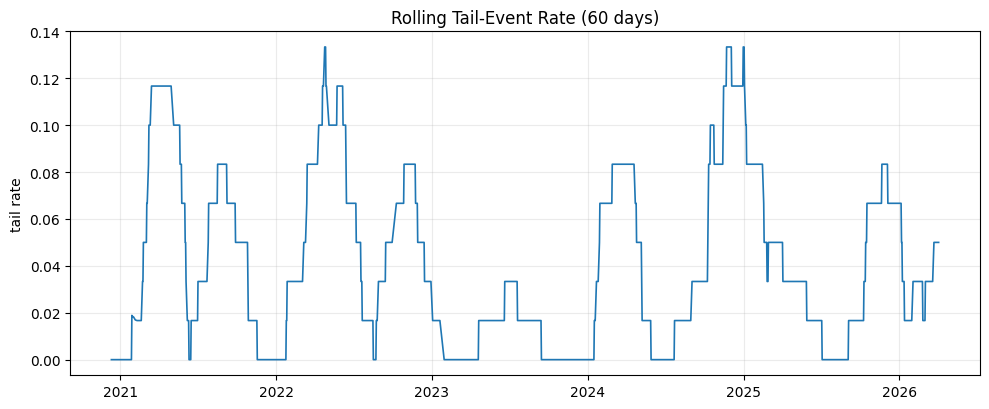

In [4]:
tail_ts = features.set_index('trade_date')['y_tail'].astype(float)
roll = tail_ts.rolling(60, min_periods=20).mean()

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(roll.index, roll.values, linewidth=1.2)
ax.set_title('Rolling Tail-Event Rate (60 days)')
ax.set_ylabel('tail rate')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 2) Why the tail label is meaningful

A reader needs evidence that `y_tail` is not an arbitrary binary flag.

This section provides that evidence in two ways:
- It compares `portfolio_return` and `tail_loss` across `y_tail=0` and `y_tail=1`.
- It shows how the conditioning features behave around those labels.

What to look for:
- Tail windows should have clearly worse return behavior.
- Tail-loss should separate the tail and non-tail states sharply.
- Volatility-related features should also show regime differences, even if not perfectly clean.

If these separations are visible, then the dataset is carrying a coherent market-stress notion into C-module training.


In [5]:
cols = ['portfolio_return', 'tail_loss', 'cumret_5d', 'vol_20d', 'amount_change_5d']
by_label = features.groupby('y_tail')[cols].agg(['mean', 'std', 'median'])
display(by_label)
display(descriptive)


portfolio_return                     tail_loss                     cumret_5d                       vol_20d                     amount_change_5d                    
                   mean       std    median      mean       std    median      mean       std    median      mean       std    median             mean       std    median
y_tail                                                                                                                                                                    
0              0.001533  0.013431 -0.000329 -0.001533  0.013431  0.000329  0.001645  0.032934  0.000402  0.013386  0.006625  0.012204        -0.007537  0.383895 -0.012652
1             -0.034221  0.015998 -0.030068  0.034221  0.015998  0.030068 -0.029374  0.069080 -0.036157  0.019181  0.011058  0.016079         0.248074  0.518860  0.251437

,feature,count,mean,std,q05,q50,q95,min,max
0,portfolio_return,1303,0.000051,0.015302,-0.022025,-0.000842,0.022603,-0.108320,0.144742
1,tail_loss,1303,-0.000051,0.015302,-0.022603,0.000842,0.022025,-0.144742,0.108320
2,cumret_5d,1299,0.000356,0.035675,-0.048686,-0.000651,0.047308,-0.190726,0.413048
3,vol_20d,1284,0.013630,0.006961,0.007516,0.012372,0.022883,0.006366,0.058960
4,amount_change_5d,1299,0.003089,0.393500,-0.593727,0.000270,0.620951,-1.519263,2.211196


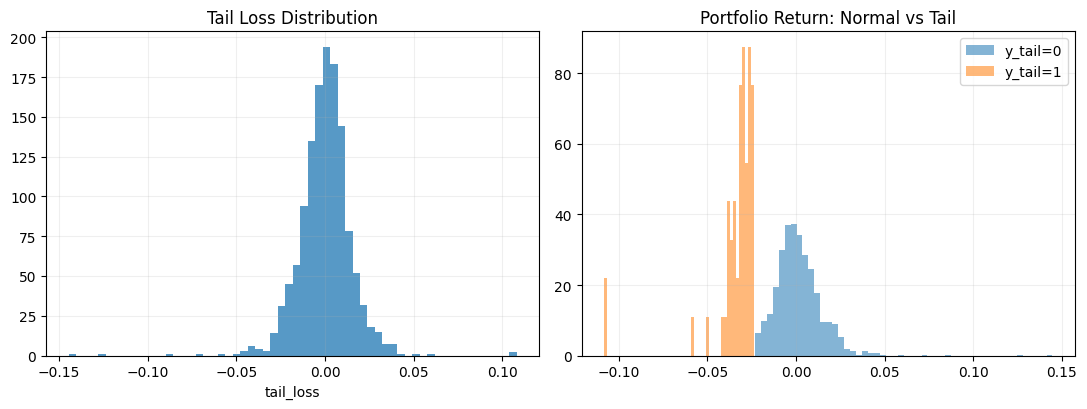

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

tail_loss = features['tail_loss'].astype(float)
axes[0].hist(tail_loss, bins=60, alpha=0.75)
axes[0].set_title('Tail Loss Distribution')
axes[0].set_xlabel('tail_loss')

x0 = features.loc[features['y_tail'] == 0, 'portfolio_return'].astype(float)
x1 = features.loc[features['y_tail'] == 1, 'portfolio_return'].astype(float)
axes[1].hist(x0, bins=50, alpha=0.55, density=True, label='y_tail=0')
axes[1].hist(x1, bins=50, alpha=0.55, density=True, label='y_tail=1')
axes[1].set_title('Portfolio Return: Normal vs Tail')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 3) Tensor interface for the generative model

This section is the practical handoff from B to C.

What the reader should understand:
- The notebook is no longer dealing with abstract feature tables only.
- The project has already converted the panel into sequence tensors with explicit shapes.
- `X` is the 20-day multi-asset log-return path.
- `C` is the 4-dimensional condition vector.
- `y_tail` and `state_label` are the auxiliary supervision signals.

This is important because it shows that B-module is not merely descriptive feature engineering. It is the exact data interface required to train and sample from the conditional DDPM. It is also the fixed dataset interface that enabled the later 9-run calibration workflow without any B-side schema changes.


In [7]:
def npz_summary(path: Path) -> pd.DataFrame:
    d = np.load(path, allow_pickle=True)
    return pd.DataFrame(
        {
            'file': [path.name],
            'X_shape': [tuple(d['X'].shape)],
            'C_shape': [tuple(d['C'].shape)],
            'y_tail_rate': [float(d['y_tail'].mean())],
            'high_vol_rate': [float(d['state_label'].mean())],
            'start_date': [pd.to_datetime(d['trade_date']).min().date()],
            'end_date': [pd.to_datetime(d['trade_date']).max().date()],
            'condition_names': [list(d['condition_names'])],
        }
    )

pd.concat([npz_summary(TRAIN_PATH), npz_summary(VALID_PATH), npz_summary(TEST_PATH)], ignore_index=True)


,file,X_shape,C_shape,y_tail_rate,high_vol_rate,start_date,end_date,condition_names
0,dataset_train.npz,"(498, 20, 5)","(498, 4)",0.052209,0.500000,2020-12-14,2022-12-30,"[cumret_5d, vol_20d, amount_change_5d, high_vol]"
1,dataset_valid.npz,"(242, 20, 5)","(242, 4)",0.008264,0.000000,2023-01-03,2023-12-29,"[cumret_5d, vol_20d, amount_change_5d, high_vol]"
2,dataset_test.npz,"(544, 20, 5)","(544, 4)",0.047794,0.597426,2024-01-02,2026-04-03,"[cumret_5d, vol_20d, amount_change_5d, high_vol]"


## 4) What B-module has already delivered to the full project

At this point the reader can see why B-module is more than a preprocessing appendix.

It has already delivered:
- A balanced panel aligned across all 5 assets.
- A 4-factor conditional interface for C-module.
- Explicit tail labels and volatility-state labels for risk-oriented learning.
- Time-split datasets that can support end-to-end training and evaluation.

The main limitation is also clear and honest:
- The validation split is too calm relative to train and test, so it is useful as a continuity check but weaker as a stress-regime selector.

In the current project stage, that means B-module should be read as stable enough to support meaningful calibration experiments. The key open question has shifted downstream: can C/D use this fixed interface to improve both distribution fit and tail-risk alignment at the same time?

This is the correct transition point into C-module, where these tensors become the direct input to training and sampling.
